In [1]:
!pip install -q datasets sentencepiece sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 3.0 MB/s eta 0:00:00


In [2]:
import os
import re
import math
import random
import time
import gc
import numpy as np
import pandas as pd
import sentencepiece as spm
from tqdm.auto import tqdm

from datasets import load_dataset
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

from sklearn.model_selection import train_test_split
from sacrebleu import corpus_bleu
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [5]:
dataset = load_dataset("Jonibek21/English-Uzbek-Translation")
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/31.0 [00:00<?, ?B/s]

Translations.jsonl:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/47992 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['en', 'uz'],
        num_rows: 47992
    })
})

In [6]:
dataset["train"][0]

{'en': "For the white kitten had been having its face washed by the old cat for the last quarter of an hour (and bearing it pretty well, considering); so you see that it COULDN'T have had any hand in the mischief.",
 'uz': "Chunki oq qushning yuzi so'nggi chorak soat davomida keksa mushuk tomonidan yuvilgan edi (va buni juda yaxshi ko'rib turibdi); shuning uchun siz ko'rasizki, u yomon ishda hech qanday ishtirok etmagan."}

In [7]:
df = pd.DataFrame(dataset["train"])
df.head()

,en,uz
0,For the white kitten had been having its face ...,Chunki oq qushning yuzi so'nggi chorak soat da...
1,The way Dinah washed her children's faces was ...,Dina o'z bolalarining yuzlarini yuvish usuli q...
2,But the black kitten had been finished with ea...,"Ammo qora kichkinagina kechqurun tugadi, va sh..."
3,"'Oh, you wicked little thing!' cried Alice, ca...","O, sen yovuz kichkina narsa! - deb baqirib yub..."
4,"'Really, Dinah ought to have taught you better...","Haqiqatan ham, Dina sizga yaxshi xulq-atvorni ..."


In [8]:
def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text

In [9]:
df["en"] = df["en"].apply(clean_text)
df["uz"] = df["uz"].apply(clean_text)

In [10]:
df.shape

(47992, 2)

In [11]:
df = df.dropna()
df = df[
    (df["en"].str.len() > 0) &
    (df["uz"].str.len() > 0)
]
df = df.drop_duplicates()
df = df.reset_index(drop=True)
df.shape

(47984, 2)

In [12]:
max(df["en"].str.split().str.len()), max(df["uz"].str.split().str.len())

(188, 492)

In [13]:
df[df["uz"].str.split().str.len() == 492]

,en,uz
835,she started to her feet and sprang across the ...,u qo'rquvda o'z oyoqlaridan turdi va ozgina da...
998,'the eighth square at last!' she cried as she ...,"negacha sakkizinchi maydon! - deb baqirib, o'z..."


In [14]:
df = df[df["uz"].str.split().str.len() != 492]

In [15]:
MAX_LEN = 80

df = df[df["en"].str.split().str.len() <= MAX_LEN]
df = df[df["uz"].str.split().str.len() <= MAX_LEN]
df = df.reset_index(drop=True)
df.shape

(46534, 2)

In [16]:
train_df, valid_df = train_test_split(df, test_size=0.05, random_state=SEED, shuffle=True)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

print(train_df.shape)
print(valid_df.shape)

(44207, 2)
(2327, 2)


In [17]:
with open("spm_input.txt", "w", encoding="utf-8") as f:
    for text in train_df["en"]:
        f.write(text + "\n")
    for text in train_df["uz"]:
        f.write(text + "\n")

In [18]:
VOCAB_SIZE = 16000

spm.SentencePieceTrainer.train(
    input="spm_input.txt",
    model_prefix="spm",
    vocab_size=VOCAB_SIZE,
    character_coverage=1.0,
    model_type="bpe",
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3,
    pad_piece="[PAD]",
    unk_piece="[UNK]",
    bos_piece="[BOS]",
    eos_piece="[EOS]"
)

In [19]:
sp = spm.SentencePieceProcessor()
sp.load("spm.model")

True

In [20]:
text = "i love artificial intelligence"
tokens = sp.encode(text)
tokens

[29, 1138, 2038, 3453, 2063, 8113]

In [21]:
sp.decode(tokens)

'i love artificial intelligence'

In [22]:
PAD_IDX = sp.pad_id()
UNK_IDX = sp.unk_id()
BOS_IDX = sp.bos_id()
EOS_IDX = sp.eos_id()

PAD_IDX, UNK_IDX, BOS_IDX, EOS_IDX

(0, 1, 2, 3)

In [23]:
def encode_text(text):
    tokens = sp.encode(text)
    tokens = [BOS_IDX] + tokens + [EOS_IDX]
    return tokens

In [24]:
sample = train_df["en"][0]
print(sample)
encoded = encode_text(sample)
print(encoded)

i am verily he who slew yonder man this morning towards daybreak and i saw this poor wretch asleep there, what while i was in act to divide the booty gotten with him whom i slew.
[2, 29, 202, 3436, 913, 56, 328, 4161, 15863, 7609, 297, 261, 1580, 1778, 14073, 51, 29, 909, 261, 1591, 11639, 3662, 259, 15858, 355, 1308, 29, 111, 67, 2052, 39, 5162, 439, 16, 8380, 15855, 9820, 139, 171, 1419, 29, 4161, 15863, 15864, 3]


In [25]:
train_lengths = train_df["en"].apply(lambda x: len(encode_text(x)))
train_lengths.describe()

,en
count,44207.000000
mean,30.847694
std,19.797436
min,4.000000
25%,16.000000
50%,26.000000
75%,40.000000
max,133.000000


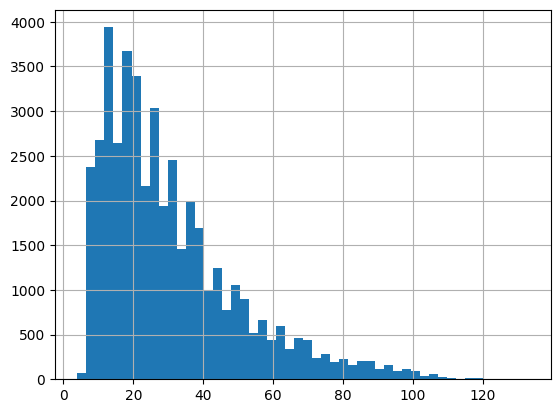

In [26]:
train_lengths.hist(bins=50)
plt.show()

In [27]:
class TranslationDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        src_text = self.df.iloc[idx]["en"]
        trg_text = self.df.iloc[idx]["uz"]

        src_ids = encode_text(src_text)
        trg_ids = encode_text(trg_text)

        return {
            "src_ids": torch.tensor(src_ids),
            "trg_ids": torch.tensor(trg_ids)
        }

In [28]:
train_dataset = TranslationDataset(train_df)
valid_dataset = TranslationDataset(valid_df)

len(train_dataset), len(valid_dataset)

(44207, 2327)

In [29]:
def collate_fn(batch):
    src_batch = [x["src_ids"] for x in batch]
    trg_batch = [x["trg_ids"] for x in batch]

    src_lengths = torch.tensor([len(x) for x in src_batch], dtype=torch.long)

    src_batch = pad_sequence(src_batch, batch_first=True, padding_value=PAD_IDX)
    trg_batch = pad_sequence(trg_batch, batch_first=True, padding_value=PAD_IDX)

    return {
        "src": src_batch,
        "trg": trg_batch,
        "src_lengths": src_lengths
    }

In [30]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, pin_memory=True)

In [31]:
batch = next(iter(train_loader))

print(batch["src"].shape)
print(batch["trg"].shape)
print(batch["src_lengths"].shape)

torch.Size([32, 94])
torch.Size([32, 110])
torch.Size([32])


In [32]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size

        self.emb = nn.Embedding(vocab_size, emb_size, padding_idx=PAD_IDX)
        self.dropout = nn.Dropout(dropout)

        self.gru = nn.GRU(emb_size, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, hidden_size)

    def forward(self, src, src_lengths):
        embedded = self.emb(src)
        embedded = self.dropout(embedded)
        packed = pack_padded_sequence(embedded, src_lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_outputs, hidden = self.gru(packed)

        outputs, _ = pad_packed_sequence(packed_outputs, batch_first=True)

        hidden = hidden.view(self.num_layers, 2, src.size(0), self.hidden_size)

        forward_hidden = hidden[-1, 0]
        backward_hidden = hidden[-1, 1]

        hidden = torch.cat((forward_hidden, backward_hidden), dim=1)
        hidden = torch.tanh(self.fc(hidden))

        return outputs, hidden

In [33]:
VOCAB_SIZE = sp.get_piece_size()

EMB_SIZE = 256
HIDDEN_SIZE = 256
NUM_LAYERS = 1
DROPOUT = 0.3

In [34]:
encoder = Encoder(
    vocab_size=VOCAB_SIZE,
    emb_size=EMB_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

In [35]:
batch = next(iter(train_loader))

src = batch["src"].to(device)
src_lengths = batch["src_lengths"]

encoder_output, hidden = encoder(src, src_lengths)

encoder_output.shape, hidden.shape

(torch.Size([32, 119, 512]), torch.Size([32, 256]))

In [36]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_size, hidden_size, num_layers, dropout):
        super().__init__()

        self.hidden_size = hidden_size
        self.emb = nn.Embedding(vocab_size, emb_size, padding_idx=PAD_IDX)
        self.dropout = nn.Dropout(dropout)

        self.gru = nn.GRU(
            input_size=emb_size + hidden_size * 2,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc_out = nn.Linear(hidden_size + hidden_size * 2 + emb_size, vocab_size)

        self.Wa = nn.Linear(hidden_size, hidden_size)
        self.Ua = nn.Linear(hidden_size * 2, hidden_size)
        self.Va = nn.Linear(hidden_size, 1)

    def forward(self, input_token, hidden, encoder_outputs):
        input_token = input_token.unsqueeze(1)
        embedded = self.emb(input_token)
        embedded = self.dropout(embedded)
        query = hidden.unsqueeze(1)

        scores = self.Va(torch.tanh(self.Wa(query) + self.Ua(encoder_outputs)))
        attention_weights = torch.softmax(scores, dim=1)

        context = torch.sum(attention_weights * encoder_outputs, dim=1, keepdim=True)

        gru_input = torch.cat((embedded, context), dim=2)

        output, hidden = self.gru(gru_input, hidden.unsqueeze(0))

        output = output.squeeze(1)
        context = context.squeeze(1)
        embedded = embedded.squeeze(1)
        hidden = hidden.squeeze(0)

        prediction = self.fc_out(torch.cat((output, context, embedded), dim=1))

        return prediction, hidden, attention_weights

In [37]:
decoder = Decoder(
    vocab_size=VOCAB_SIZE,
    emb_size=EMB_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

In [38]:
batch = next(iter(train_loader))

src = batch["src"].to(device)
trg = batch["trg"].to(device)
src_lengths = batch["src_lengths"]

In [39]:
encoder_outputs, hidden = encoder(src, src_lengths)

print(encoder_outputs.shape)
print(hidden.shape)

torch.Size([32, 72, 512])
torch.Size([32, 256])


In [40]:
input_token = trg[:, 0]

print(input_token.shape)

torch.Size([32])


In [41]:
prediction, hidden, attention_weights = decoder(input_token, hidden, encoder_outputs)

print("prediction:", prediction.shape)
print("hidden:", hidden.shape)
print("attention:", attention_weights.shape)

prediction: torch.Size([32, 16000])
hidden: torch.Size([32, 256])
attention: torch.Size([32, 72, 1])


In [42]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, src_lengths, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(batch_size, trg_len, vocab_size).to(self.device)

        encoder_outputs, hidden = self.encoder(src, src_lengths)
        input_token = trg[:, 0]

        for t in range(1, trg_len):
            output, hidden, _ = self.decoder(input_token, hidden, encoder_outputs)
            outputs[:, t] = output
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input_token = (trg[:, t] if teacher_force else top1)

        return outputs

In [43]:
encoder = Encoder(vocab_size=VOCAB_SIZE, emb_size=EMB_SIZE, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT)
decoder = Decoder(vocab_size=VOCAB_SIZE, emb_size=EMB_SIZE, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT)

model = Seq2Seq(encoder, decoder, device).to(device)

In [44]:
batch = next(iter(train_loader))

src = batch["src"].to(device)
trg = batch["trg"].to(device)
src_lengths = batch["src_lengths"]

In [45]:
outputs = model(src, src_lengths, trg)

print(outputs.shape)

torch.Size([32, 128, 16000])


In [46]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

In [47]:
optimizer = optim.AdamW(model.parameters(), lr=3e-4)

In [48]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)

In [49]:
scaler = torch.amp.GradScaler("cuda")

In [50]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Trainable params: {total_params:,}")

Trainable params: 26,498,177


In [51]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, clip=1.0):
    model.train()
    epoch_loss = 0
    progress_bar = tqdm(loader)

    for batch in progress_bar:
        src = batch["src"].to(device)
        trg = batch["trg"].to(device)
        src_lengths = batch["src_lengths"]

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            output = model(src, src_lengths, trg)
            output_dim = output.shape[-1]
            output = output[:, 1:].reshape(-1, output_dim)
            trg = trg[:, 1:].reshape(-1)
            loss = criterion(output, trg)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        progress_bar.set_description(f"Loss: {loss.item():.4f}")

    return epoch_loss / len(loader)

In [52]:
def evaluate(model, loader, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for batch in tqdm(loader):
            src = batch["src"].to(device)
            trg = batch["trg"].to(device)
            src_lengths = batch["src_lengths"]

            output = model(src, src_lengths, trg, teacher_forcing_ratio=0)
            output_dim = output.shape[-1]

            output = output[:, 1:].reshape(-1, output_dim)
            trg = trg[:, 1:].reshape(-1)

            loss = criterion(output, trg)
            epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [53]:
N_EPOCHS = 10

best_valid_loss = float("inf")

train_losses = []
valid_losses = []

In [54]:
for epoch in range(N_EPOCHS):
    print(f"\nEpoch [{epoch+1}/{N_EPOCHS}]")

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
    valid_loss = evaluate(model, valid_loader, criterion)

    scheduler.step(valid_loss)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Valid Loss: {valid_loss:.4f}")

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), "best_model.pt")
        print("Best model saved!")

    torch.cuda.empty_cache()
    gc.collect()


Epoch [1/10]


  0%|          | 0/1382 [00:00<?, ?it/s]

  0%|          | 0/73 [00:00<?, ?it/s]

Train Loss: 6.0031
Valid Loss: 6.1902
Best model saved!

Epoch [2/10]


  0%|          | 0/1382 [00:00<?, ?it/s]

...

  0%|          | 0/73 [00:00<?, ?it/s]

Train Loss: 3.9132
Valid Loss: 5.7364

Epoch [10/10]


  0%|          | 0/1382 [00:00<?, ?it/s]

  0%|          | 0/73 [00:00<?, ?it/s]

Train Loss: 3.7590
Valid Loss: 5.6699
Best model saved!


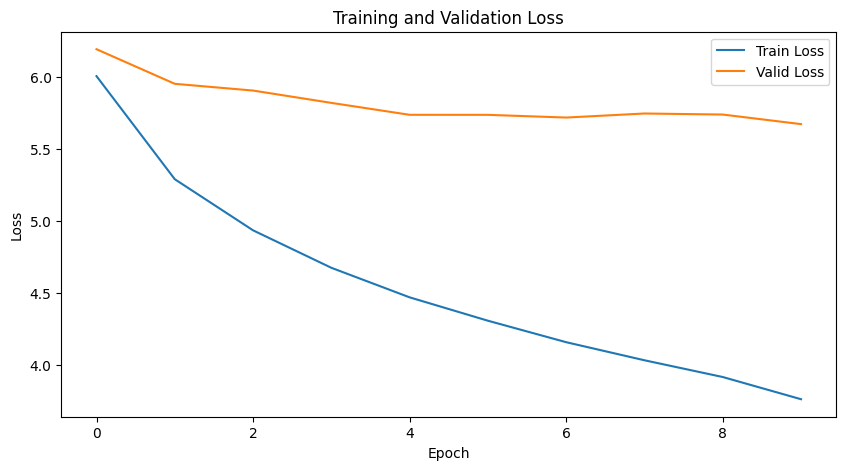

In [55]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(valid_losses, label="Valid Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

In [56]:
def translate(sentence, model, sp, device, max_len=50):
    model.eval()

    tokens = encode_text(sentence)
    src_tensor = torch.tensor(tokens).unsqueeze(0).to(device)
    src_lengths = torch.tensor([len(tokens)], dtype=torch.long)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor, src_lengths)

    trg_ids = [BOS_IDX]

    for _ in range(max_len):
        input_token = torch.tensor([trg_ids[-1]]).to(device)

        with torch.no_grad():
            output, hidden, _ = model.decoder(input_token, hidden, encoder_outputs)

        pred_id = output.argmax(1).item()
        trg_ids.append(pred_id)

        if pred_id == EOS_IDX:
            break

    trg_ids = trg_ids[1:]
    if EOS_IDX in trg_ids:
        trg_ids = trg_ids[:trg_ids.index(EOS_IDX)]

    return sp.decode(trg_ids)

In [75]:
model.load_state_dict(torch.load("best_model.pt", map_location=device))

test_sentences = [
    "I am living alone now",
    "it is empty.",
    "it is so cold",
    "you are thirsty",
    "how it works in real world"
]

for sentence in test_sentences:
    translation = translate(sentence, model, sp, device)
    print(f"EN: {sentence}")
    print(f"UZ: {translation}")
    print()

EN: I am living alone now
UZ: endi yolg'iz yolg'iz bo'lgan.

EN: it is empty.
UZ: bu'sh.

EN: it is so cold
UZ: shunday sovuq sovuq sovuq sovuq sovuq.

EN: you are thirsty
UZ: siz chan''siz.

EN: how it works in real world
UZ: bu qanday bo'''



In [58]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses": train_losses,
    "valid_losses": valid_losses,
    "best_valid_loss": best_valid_loss,
    "vocab_size": VOCAB_SIZE,
    "emb_size": EMB_SIZE,
    "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS,
    "dropout": DROPOUT,
}, "seq2seq_checkpoint.pt")

print("Checkpoint saved: seq2seq_checkpoint.pt")

Checkpoint saved: seq2seq_checkpoint.pt


In [59]:
from google.colab import files

files.download("seq2seq_checkpoint.pt")
files.download("spm.model")
files.download("spm.vocab")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>